# Part A – Setup & Dataset Loading
## Q1. Import required libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

## Q2. Load the dataset from your local path (after Kaggle download)

In [2]:
data = pd.read_csv("student_performance.csv")
data.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


# Part B – Data Understanding
## Q3. Display basic statistics and check for missing values.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


In [4]:
data.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278932,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


In [5]:
data.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

## Q4. Create a scatter plot showing how study hours affect total scores.

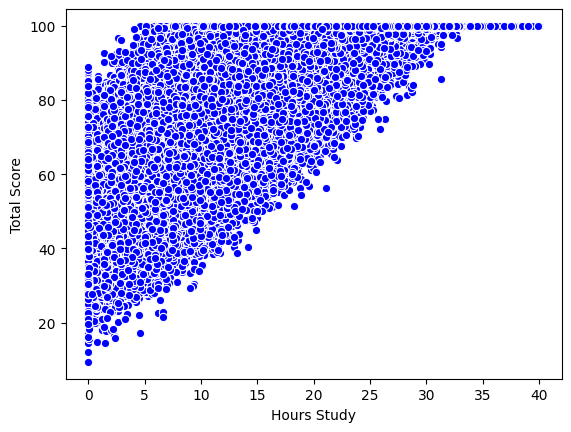

In [6]:
plt.scatter(data["weekly_self_study_hours"], data["total_score"], color="blue", edgecolor='white', linewidth=0.8)
plt.xlabel("Hours Study")
plt.ylabel("Total Score")
plt.show()

## Q5. Visualize relationships between study hours, attendance, and total score. (Deep into)

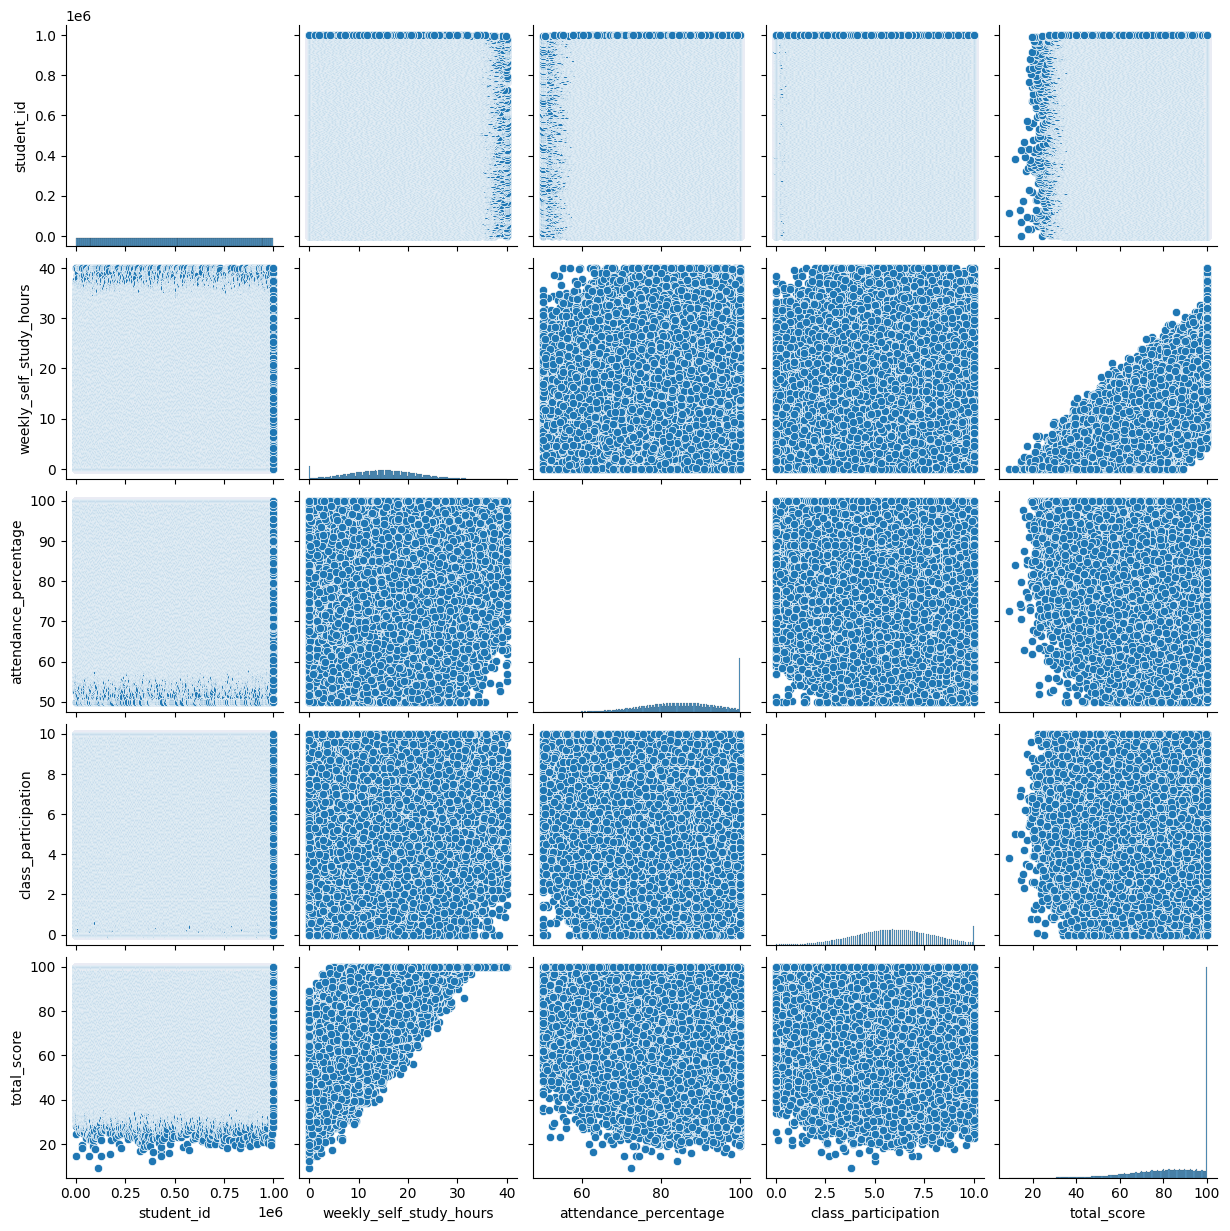

In [7]:
sns.pairplot(data)
plt.show()

# Part C – Model Training (Linear Regression)
## Q6. Define features (X) and target (y).

In [8]:
x = data[["weekly_self_study_hours", "attendance_percentage", "class_participation"]]
y = data["total_score"]

## Q7. Split data into train and test sets.

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Q8. Train a Linear Regression model.

In [10]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Part D – Model Interpretation

## Q9. Print the regression coefficients and intercept.

In [11]:
print("Linear Coefficient: ", linear_model.coef_)
print("Linear Intercept: ", linear_model.intercept_)

Linear Coefficient:  [ 1.81682003e+00  4.01750743e-04 -2.75562094e-03]
Linear Intercept:  56.953557444770254


# Part E – Feature Importance (Tree-based Comparison)
## Q11. Train a Random Forest model for comparison.

In [12]:
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(x_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Q12. Extract and visualize feature importance

Text(0.5, 1.0, 'Feature importance(Random forest)')

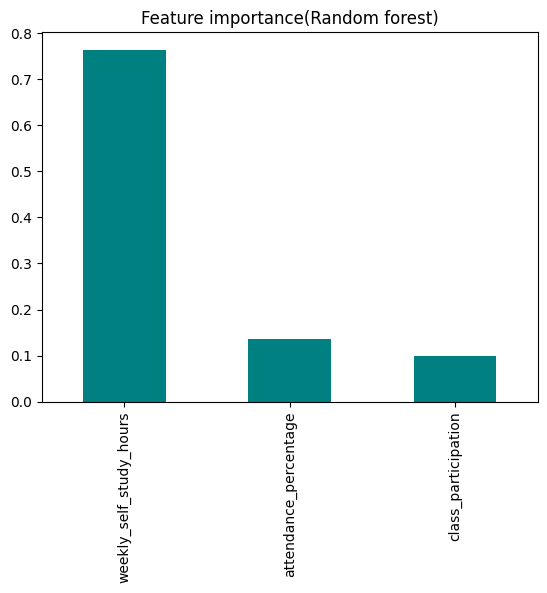

In [13]:
importances = pd.Series(random_forest_model.feature_importances_, index=x.columns)
importances.plot(kind='bar', color='teal')
plt.title("Feature importance(Random forest)")

# Part F – Reflection Questions

## Q13. Which feature has the highest impact in Linear Regression?

weekly_self_study_hours
It has the largest coefficient (1.8168).

## Q14. Which feature has the highest importance in Random Forest?

weekly_self_study_hours

## Q15. What’s the main difference between Linear Regression and Random Forest interpretability?

Linear Regression: Direct mathematical coefficients (easy to interpret).

Random Forest: Relative importance — shows which features matter most, not how.

## Q16. Why is interpretability important in analytics?

Builds trust and transparency.

Helps identify which factors influence performance most.

## Q17. Visualize actual vs predicted scores.